# 04 Decision Tree Depth Analysis

This notebook compares Decision Tree models with `max_depth` values from 1 through 25. It uses only the training and validation datasets. The test set is not loaded or used.

## Why Compare Tree Depths?

Tree depth controls model complexity. A very shallow tree may underfit because it cannot learn enough useful rules. A very deep tree may overfit because it can memorize training patterns that do not generalize as well. Validation performance helps us judge this tradeoff without touching the final test set.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.analyze_depth import (
    DEPTH_ACCURACY_FIGURE,
    DEPTH_F1_FIGURE,
    compare_tree_depths,
    save_depth_figures,
)

## Train Trees From Depth 1 Through 25

For each depth, we record training accuracy, validation accuracy, training F1 for phishing, validation F1 for phishing, actual tree depth, and number of leaves. Phishing (`label 0`) is treated as the positive class.

In [2]:
depth_results = compare_tree_depths()
save_depth_figures(depth_results)
depth_results.round(4)

,max_depth,training_accuracy,validation_accuracy,training_f1_phishing,validation_f1_phishing,tree_depth,leaves
0,1,0.8288,0.8266,0.7500,0.7461,1,2
1,2,0.9905,0.9901,0.9888,0.9883,2,3
2,3,0.9929,0.9924,0.9917,0.9911,3,4
3,4,0.9946,0.9941,0.9937,0.9931,4,6
4,5,0.9949,0.9946,0.9940,0.9936,5,9
5,6,0.9949,0.9946,0.9940,0.9936,6,14
6,7,0.9950,0.9946,0.9941,0.9937,7,22
7,8,0.9955,0.9952,0.9947,0.9943,8,31
8,9,0.9957,0.9951,0.9950,0.9942,9,45
9,10,0.9958,0.9953,0.9951,0.9945,10,63


At depth 1, the model is too simple and underfits. From depths 2 to about 8, validation scores improve quickly as the tree gains useful rules. After that, training performance continues to increase slightly, while validation performance changes very little.

## Accuracy Curve

This graph compares training accuracy and validation accuracy across depths.

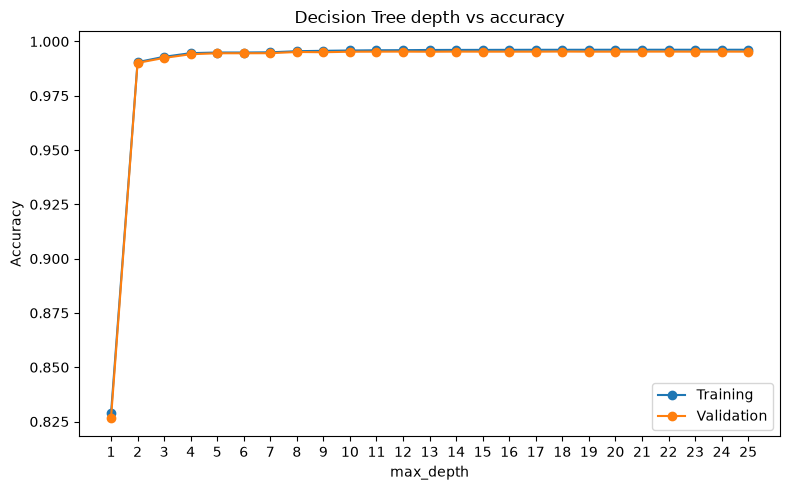

WindowsPath('D:/Projects/phishing-url-detection/reports/figures/tree_depth_accuracy.png')

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(depth_results["max_depth"], depth_results["training_accuracy"], marker="o", label="Training")
plt.plot(depth_results["max_depth"], depth_results["validation_accuracy"], marker="o", label="Validation")
plt.title("Decision Tree depth vs accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.xticks(depth_results["max_depth"])
plt.legend()
plt.tight_layout()
plt.show()

DEPTH_ACCURACY_FIGURE

Validation accuracy matters more than training accuracy for choosing model complexity because it estimates performance on data the model did not fit directly.

## Phishing F1-Score Curve

F1-score balances phishing precision and phishing recall, which is useful because phishing is the security-focused positive class.

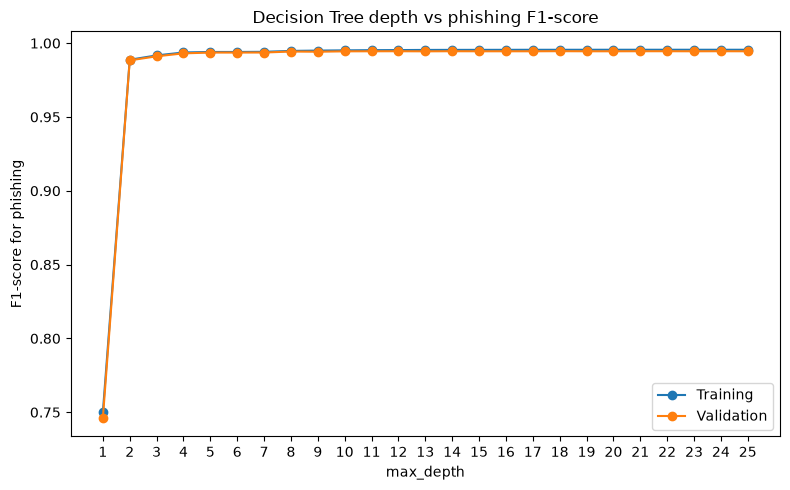

WindowsPath('D:/Projects/phishing-url-detection/reports/figures/tree_depth_f1.png')

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(depth_results["max_depth"], depth_results["training_f1_phishing"], marker="o", label="Training")
plt.plot(depth_results["max_depth"], depth_results["validation_f1_phishing"], marker="o", label="Validation")
plt.title("Decision Tree depth vs phishing F1-score")
plt.xlabel("max_depth")
plt.ylabel("F1-score for phishing")
plt.xticks(depth_results["max_depth"])
plt.legend()
plt.tight_layout()
plt.show()

DEPTH_F1_FIGURE

## Promising Depth Range

Depth 1 clearly underfits. Depths around 8 through 18 appear promising because validation accuracy and phishing F1-score are already very high, while the tree is simpler than the unrestricted baseline. This notebook does not select the final model; it only identifies a sensible range for later tuning.

In [5]:
best_validation_f1_row = depth_results.loc[depth_results["validation_f1_phishing"].idxmax()]
best_validation_accuracy_row = depth_results.loc[depth_results["validation_accuracy"].idxmax()]

pd.DataFrame(
    [
        {
            "criterion": "Best validation phishing F1",
            "max_depth": int(best_validation_f1_row["max_depth"]),
            "validation_accuracy": best_validation_f1_row["validation_accuracy"],
            "validation_f1_phishing": best_validation_f1_row["validation_f1_phishing"],
            "leaves": int(best_validation_f1_row["leaves"]),
        },
        {
            "criterion": "Best validation accuracy",
            "max_depth": int(best_validation_accuracy_row["max_depth"]),
            "validation_accuracy": best_validation_accuracy_row["validation_accuracy"],
            "validation_f1_phishing": best_validation_accuracy_row["validation_f1_phishing"],
            "leaves": int(best_validation_accuracy_row["leaves"]),
        },
    ]
).round(4)

,criterion,max_depth,validation_accuracy,validation_f1_phishing,leaves
0,Best validation phishing F1,18,0.9954,0.9946,302
1,Best validation accuracy,18,0.9954,0.9946,302
